In [13]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("gifgif_emotion_labels.csv")

group_defs = {
    "positive_energetic": ["happiness_score","amusement_score","excitement_score","relief_score"],
    "positive_calm":      ["satisfaction_score","contentment_score","pleasure_score","pride_score"],
    "negative_intense":   ["anger_score","fear_score","disgust_score"],
    "negative_subdued":   ["sadness_score","embarrassment_score","guilt_score","shame_score"],
    "surprise":           ["surprise_score"],
    "contempt":           ["contempt_score"],
}

# Compute grouped scores (max works best for emotion)
for g, cols in group_defs.items():
    df[g+"_gscore"] = df[cols].max(axis=1)

groups = list(group_defs.keys())
G = df[[g+"_gscore" for g in groups]].values

Top group always + any group within 85% of top

In [15]:
alpha = 0.85

top = G.max(axis=1, keepdims=True)
Y = (G >= (alpha * top)).astype(np.float32)

df_multi = df.copy()
for i, g in enumerate(groups):
    df_multi[g] = Y[:, i]

print("Average labels per GIF:", Y.sum(axis=1).mean())
print("Max labels on a GIF:", int(Y.sum(axis=1).max()))

Average labels per GIF: 1.2779872
Max labels on a GIF: 4


In [16]:
pos = Y.sum(axis=0)
neg = Y.shape[0] - pos

imbalance_df = pd.DataFrame({
    "label": groups,
    "positives": pos.astype(int),
    "pos_rate": np.round(pos / Y.shape[0], 4),
    "neg_to_pos_ratio": np.round(neg / np.maximum(pos, 1), 2)
}).sort_values("pos_rate")

print(imbalance_df.to_string(index=False))

             label  positives  pos_rate  neg_to_pos_ratio
          contempt        324    0.0531             17.83
          surprise        698    0.1144              7.74
  negative_subdued       1341    0.2198              3.55
     positive_calm       1434    0.2350              3.25
  negative_intense       1781    0.2919              2.43
positive_energetic       2219    0.3637              1.75


In [17]:
print(df.columns)

Index(['gif_id', 'gif_path', 'primary_emotion', 'primary_score',
       'total_comparisons', 'pleasure_score', 'disgust_score',
       'happiness_score', 'pride_score', 'excitement_score',
       'embarrassment_score', 'surprise_score', 'sadness_score', 'fear_score',
       'satisfaction_score', 'guilt_score', 'contempt_score', 'shame_score',
       'anger_score', 'amusement_score', 'contentment_score', 'relief_score',
       'positive_energetic_gscore', 'positive_calm_gscore',
       'negative_intense_gscore', 'negative_subdued_gscore', 'surprise_gscore',
       'contempt_gscore'],
      dtype='str')


In [18]:
alpha = 0.85

G = df[[g+"_gscore" for g in groups]].values
top = G.max(axis=1, keepdims=True)

Y = (G >= (alpha * top)).astype(np.float32)

for i, g in enumerate(groups):
    df[g] = Y[:, i]

print("Columns after adding multi-label targets:")
print(df.columns)
print("\nCheck first rows:")
print(df[groups].head())

Columns after adding multi-label targets:
Index(['gif_id', 'gif_path', 'primary_emotion', 'primary_score',
       'total_comparisons', 'pleasure_score', 'disgust_score',
       'happiness_score', 'pride_score', 'excitement_score',
       'embarrassment_score', 'surprise_score', 'sadness_score', 'fear_score',
       'satisfaction_score', 'guilt_score', 'contempt_score', 'shame_score',
       'anger_score', 'amusement_score', 'contentment_score', 'relief_score',
       'positive_energetic_gscore', 'positive_calm_gscore',
       'negative_intense_gscore', 'negative_subdued_gscore', 'surprise_gscore',
       'contempt_gscore', 'positive_energetic', 'positive_calm',
       'negative_intense', 'negative_subdued', 'surprise', 'contempt'],
      dtype='str')

Check first rows:
   positive_energetic  positive_calm  negative_intense  negative_subdued  \
0                 0.0            0.0               1.0               0.0   
1                 1.0            0.0               0.0              

In [19]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

4270 915 916


In [21]:
class GIFMultiLabelDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        gif_path = row["gif_path"]
        
        gif = Image.open(gif_path)
        frame = gif.convert("RGB")
        
        if self.transform:
            frame = self.transform(frame)
        
        label = torch.tensor(row[groups].values.astype(np.float32))
        
        return frame, label

In [22]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_ds = GIFMultiLabelDataset(train_df, transform_train)
val_ds   = GIFMultiLabelDataset(val_df, transform_eval)
test_ds  = GIFMultiLabelDataset(test_df, transform_eval)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

num_classes = 6

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
pos = torch.tensor(Y.sum(axis=0), dtype=torch.float32)
neg = torch.tensor(len(Y) - pos, dtype=torch.float32)

pos_weight = (neg / (pos + 1e-6)).clamp(max=10.0)

print("pos_weight:", pos_weight)

pos_weight: tensor([ 1.7494,  3.2545,  2.4256,  3.5496,  7.7407, 10.0000])


C:\Users\akind\AppData\Local\Temp\ipykernel_12268\2696220420.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  neg = torch.tensor(len(Y) - pos, dtype=torch.float32)


In [25]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [26]:
print(train_df[groups].head())
print("Any NaNs in labels?", train_df[groups].isna().any().any())

      positive_energetic  positive_calm  negative_intense  negative_subdued  \
1211                 0.0            1.0               0.0               0.0   
122                  0.0            0.0               1.0               0.0   
5710                 0.0            0.0               0.0               1.0   
5137                 0.0            0.0               1.0               0.0   
4879                 0.0            1.0               0.0               0.0   

      surprise  contempt  
1211       0.0       0.0  
122        0.0       0.0  
5710       0.0       0.0  
5137       0.0       0.0  
4879       0.0       0.0  
Any NaNs in labels? False


In [29]:
def evaluate(loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    
    return micro, macro


from tqdm import tqdm

EPOCHS = 20
best_macro = 0.0
best_path = "best_multilabel_6group_resnet18.pth"

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    micro, macro = evaluate(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Micro-F1: {micro:.4f} | "
          f"Macro-F1: {macro:.4f}")

    # Save best model based on Macro-F1
    if macro > best_macro:
        best_macro = macro
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model (Macro-F1 = {best_macro:.4f})")

Epoch 1: 100%|██████████| 534/534 [09:04<00:00,  1.02s/it]



Epoch 1/20 | Loss: 1.0135 | Micro-F1: 0.3705 | Macro-F1: 0.3162
✅ Saved new best model (Macro-F1 = 0.3162)


Epoch 2: 100%|██████████| 534/534 [08:52<00:00,  1.00it/s]



Epoch 2/20 | Loss: 1.0001 | Micro-F1: 0.3772 | Macro-F1: 0.3452
✅ Saved new best model (Macro-F1 = 0.3452)


Epoch 3: 100%|██████████| 534/534 [08:57<00:00,  1.01s/it]


...


Epoch 18/20 | Loss: 0.3118 | Micro-F1: 0.3854 | Macro-F1: 0.3356


Epoch 19: 100%|██████████| 534/534 [07:54<00:00,  1.12it/s]



Epoch 19/20 | Loss: 0.2954 | Micro-F1: 0.3769 | Macro-F1: 0.3268


Epoch 20: 100%|██████████| 534/534 [07:49<00:00,  1.14it/s]



Epoch 20/20 | Loss: 0.2759 | Micro-F1: 0.3885 | Macro-F1: 0.3385


Find the best threshhold

In imbalanced multi-label:

0.5 threshold often too strict

Rare classes need lower threshold (0.35–0.45)

Macro-F1 often improves significantly

In [32]:
import numpy as np
from sklearn.metrics import f1_score

# Load best model (epoch 5)
model.load_state_dict(torch.load(best_path, map_location=device))

def collect_probs_labels(loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

val_probs, val_true = collect_probs_labels(val_loader)

best_t = None
best_macro = -1

for t in np.arange(0.25, 0.61, 0.05):
    val_pred = (val_probs > t).astype(int)
    macro = f1_score(val_true, val_pred, average="macro", zero_division=0)
    print(f"Threshold {t:.2f} → Macro-F1: {macro:.4f}")
    
    if macro > best_macro:
        best_macro = macro
        best_t = t

print("\nBest threshold:", best_t)
print("Best Val Macro-F1:", best_macro)

Threshold 0.25 → Macro-F1: 0.3543
Threshold 0.30 → Macro-F1: 0.3620
Threshold 0.35 → Macro-F1: 0.3680
Threshold 0.40 → Macro-F1: 0.3753
Threshold 0.45 → Macro-F1: 0.3816
Threshold 0.50 → Macro-F1: 0.3747
Threshold 0.55 → Macro-F1: 0.3268
Threshold 0.60 → Macro-F1: 0.2744

Best threshold: 0.44999999999999996
Best Val Macro-F1: 0.38161657244697017


Test evaluation at threshold = 0.45

In [31]:
from sklearn.metrics import f1_score, classification_report

# make sure best model is loaded
model.load_state_dict(torch.load(best_path, map_location=device))

test_probs, test_true = collect_probs_labels(test_loader)
best_t = 0.45

test_pred = (test_probs > best_t).astype(int)

print("TEST Micro-F1:", f1_score(test_true, test_pred, average="micro", zero_division=0))
print("TEST Macro-F1:", f1_score(test_true, test_pred, average="macro", zero_division=0))
print("\nPer-label report:")
print(classification_report(test_true, test_pred, target_names=groups, zero_division=0))

TEST Micro-F1: 0.40897501274859765
TEST Macro-F1: 0.3720523525380875

Per-label report:
                    precision    recall  f1-score   support

positive_energetic       0.43      0.79      0.56       327
     positive_calm       0.29      0.69      0.40       240
  negative_intense       0.37      0.58      0.45       259
  negative_subdued       0.25      0.74      0.37       201
          surprise       0.14      0.53      0.23        92
          contempt       0.14      0.50      0.22        62

         micro avg       0.29      0.68      0.41      1181
         macro avg       0.27      0.64      0.37      1181
      weighted avg       0.32      0.68      0.43      1181
       samples avg       0.31      0.68      0.40      1181



Find Best Threshold Per Class (Validation)

In [33]:
import numpy as np
from sklearn.metrics import f1_score

# Make sure best model is loaded
model.load_state_dict(torch.load(best_path, map_location=device))

val_probs, val_true = collect_probs_labels(val_loader)

threshold_grid = np.arange(0.20, 0.61, 0.05)

best_thresholds = {}
best_f1s = {}

for i, label in enumerate(groups):
    best_t = 0.5
    best_f1 = 0
    
    for t in threshold_grid:
        preds = (val_probs[:, i] > t).astype(int)
        f1 = f1_score(val_true[:, i], preds, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    best_thresholds[label] = best_t
    best_f1s[label] = best_f1

print("Best thresholds per class:")
for k in best_thresholds:
    print(f"{k:20s} → threshold={best_thresholds[k]:.2f}, val_f1={best_f1s[k]:.4f}")

Best thresholds per class:
positive_energetic   → threshold=0.40, val_f1=0.5541
positive_calm        → threshold=0.50, val_f1=0.4046
negative_intense     → threshold=0.35, val_f1=0.4889
negative_subdued     → threshold=0.50, val_f1=0.4028
surprise             → threshold=0.45, val_f1=0.2857
contempt             → threshold=0.50, val_f1=0.1864


Evaluate on Test Set Using Per-Class Thresholds

In [34]:
from sklearn.metrics import classification_report

test_probs, test_true = collect_probs_labels(test_loader)

# Apply class-specific thresholds
test_pred = np.zeros_like(test_probs)

for i, label in enumerate(groups):
    t = best_thresholds[label]
    test_pred[:, i] = (test_probs[:, i] > t).astype(int)

print("TEST Micro-F1:",
      f1_score(test_true, test_pred, average="micro", zero_division=0))

print("TEST Macro-F1:",
      f1_score(test_true, test_pred, average="macro", zero_division=0))

print("\nPer-label report:")
print(classification_report(test_true, test_pred,
                            target_names=groups,
                            zero_division=0))

TEST Micro-F1: 0.41942714819427146
TEST Macro-F1: 0.3733923520654335

Per-label report:
                    precision    recall  f1-score   support

positive_energetic       0.41      0.86      0.55       327
     positive_calm       0.30      0.55      0.39       240
  negative_intense       0.33      0.86      0.48       259
  negative_subdued       0.26      0.64      0.37       201
          surprise       0.14      0.53      0.23        92
          contempt       0.15      0.47      0.23        62

         micro avg       0.30      0.71      0.42      1181
         macro avg       0.27      0.65      0.37      1181
      weighted avg       0.31      0.71      0.43      1181
       samples avg       0.31      0.72      0.42      1181



Retrain to save the history and plot the graphs

In [35]:
import os
OUT_DIR = "emotion_multilabel_figures_final"
os.makedirs(OUT_DIR, exist_ok=True)
print("Saving figures to:", OUT_DIR)

Saving figures to: emotion_multilabel_figures_final


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild model fresh
model = models.resnet18(pretrained=True)
num_classes = 6
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

# Recompute pos_weight from TRAIN LABELS (recommended)
Y_train = train_df[groups].values.astype("float32")
pos = torch.tensor(Y_train.sum(axis=0), dtype=torch.float32)
neg = torch.tensor(len(Y_train) - pos, dtype=torch.float32)
pos_weight = (neg / (pos + 1e-6)).clamp(max=10.0)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

print("pos_weight:", pos_weight)

d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


pos_weight: tensor([ 1.7250,  3.3350,  2.4242,  3.5571,  7.6263, 10.0000])


C:\Users\akind\AppData\Local\Temp\ipykernel_12268\3266579598.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  neg = torch.tensor(len(Y_train) - pos, dtype=torch.float32)


In [37]:
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm

train_losses = []
val_micro_scores = []
val_macro_scores = []

def evaluate(loader, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return micro, macro

EPOCHS = 8
best_macro = 0.0
best_path = os.path.join(OUT_DIR, "best_multilabel_6group_resnet18_final.pth")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    micro, macro = evaluate(val_loader, threshold=0.5)

    train_losses.append(avg_loss)
    val_micro_scores.append(micro)
    val_macro_scores.append(macro)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Micro-F1: {micro:.4f} | Macro-F1: {macro:.4f}")

    if macro > best_macro:
        best_macro = macro
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved best (Macro-F1={best_macro:.4f})")

print("\nBest val Macro-F1:", best_macro)
print("Best model saved to:", best_path)

Epoch 1/8: 100%|██████████| 534/534 [08:09<00:00,  1.09it/s]



Epoch 1/8 | Loss: 1.0948 | Micro-F1: 0.3455 | Macro-F1: 0.2831
✅ Saved best (Macro-F1=0.2831)


Epoch 2/8: 100%|██████████| 534/534 [07:53<00:00,  1.13it/s]



Epoch 2/8 | Loss: 1.0469 | Micro-F1: 0.3492 | Macro-F1: 0.3132
✅ Saved best (Macro-F1=0.3132)


Epoch 3/8: 100%|██████████| 534/534 [07:50<00:00,  1.13it/s]


...


Epoch 6/8 | Loss: 1.0168 | Micro-F1: 0.3393 | Macro-F1: 0.3134
✅ Saved best (Macro-F1=0.3134)


Epoch 7/8: 100%|██████████| 534/534 [07:49<00:00,  1.14it/s]



Epoch 7/8 | Loss: 1.0085 | Micro-F1: 0.3194 | Macro-F1: 0.2801


Epoch 8/8: 100%|██████████| 534/534 [08:01<00:00,  1.11it/s]



Epoch 8/8 | Loss: 0.9948 | Micro-F1: 0.3312 | Macro-F1: 0.3084

Best val Macro-F1: 0.31335178256645246
Best model saved to: emotion_multilabel_figures_final\best_multilabel_6group_resnet18_final.pth


Plot and SAVE training curves

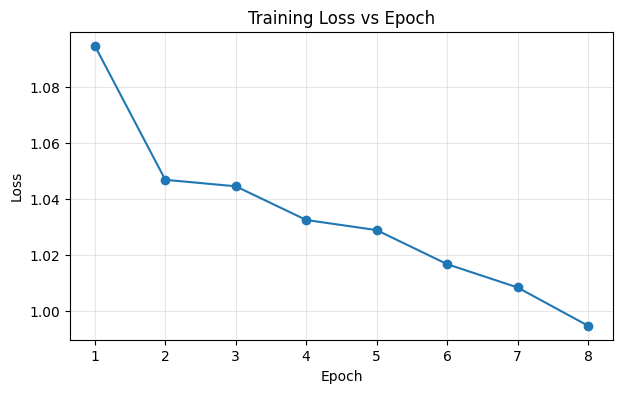

Saved: emotion_multilabel_figures_final\loss_curve.png


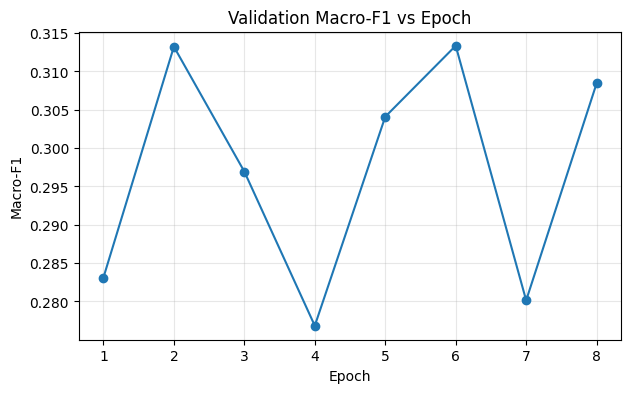

Saved: emotion_multilabel_figures_final\val_macro_f1_curve.png


In [38]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(train_losses)+1)

# Loss curve
plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses, marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
loss_path = os.path.join(OUT_DIR, "loss_curve.png")
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", loss_path)

# Macro-F1 curve
plt.figure(figsize=(7,4))
plt.plot(epochs, val_macro_scores, marker="o")
plt.title("Validation Macro-F1 vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
macro_path = os.path.join(OUT_DIR, "val_macro_f1_curve.png")
plt.savefig(macro_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", macro_path)

Collect test probs/labels with best checkpoint + choose threshold

In [39]:
from sklearn.metrics import classification_report

# Load best model
model.load_state_dict(torch.load(best_path, map_location=device))

def collect_probs_labels(loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

test_probs, test_true = collect_probs_labels(test_loader)

THRESH = 0.45
test_pred = (test_probs > THRESH).astype(int)

print("TEST Micro-F1:", f1_score(test_true, test_pred, average="micro", zero_division=0))
print("TEST Macro-F1:", f1_score(test_true, test_pred, average="macro", zero_division=0))
print("\nReport:\n", classification_report(test_true, test_pred, target_names=groups, zero_division=0))

TEST Micro-F1: 0.36130742049469966
TEST Macro-F1: 0.3356737244000238

Report:
                     precision    recall  f1-score   support

positive_energetic       0.39      0.75      0.51       327
     positive_calm       0.27      0.90      0.41       240
  negative_intense       0.32      0.48      0.39       259
  negative_subdued       0.24      0.62      0.34       201
          surprise       0.11      0.85      0.20        92
          contempt       0.10      0.47      0.16        62

         micro avg       0.24      0.69      0.36      1181
         macro avg       0.24      0.68      0.34      1181
      weighted avg       0.29      0.69      0.39      1181
       samples avg       0.26      0.70      0.36      1181



Per-class F1 bar chart (SAVE)

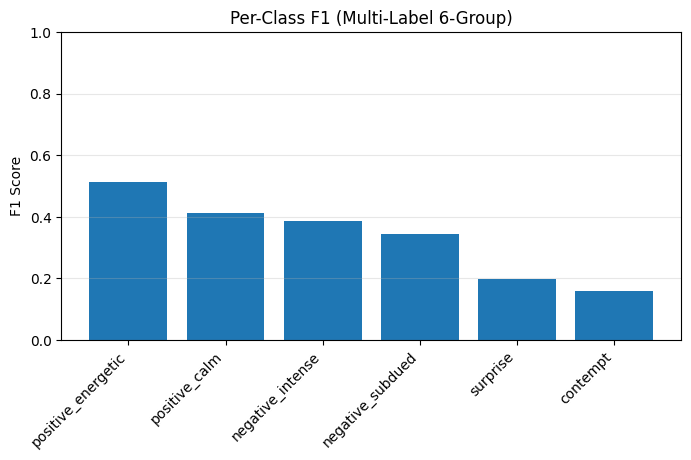

Saved: emotion_multilabel_figures_final\per_class_f1.png


In [40]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

per_class_f1 = [f1_score(test_true[:, i], test_pred[:, i], zero_division=0) for i in range(len(groups))]

plt.figure(figsize=(8,4))
plt.bar(groups, per_class_f1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 (Multi-Label 6-Group)")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
f1_path = os.path.join(OUT_DIR, "per_class_f1.png")
plt.savefig(f1_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", f1_path)

Multi-label confusion matrices (binary per class) — SAVE

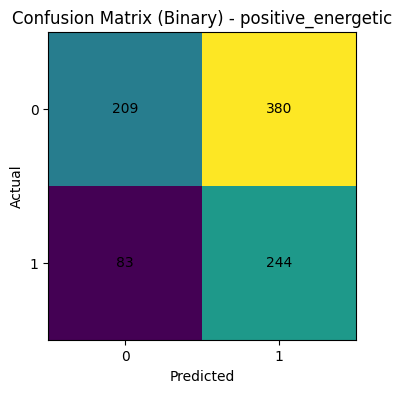

Saved: emotion_multilabel_figures_final\cm_positive_energetic.png


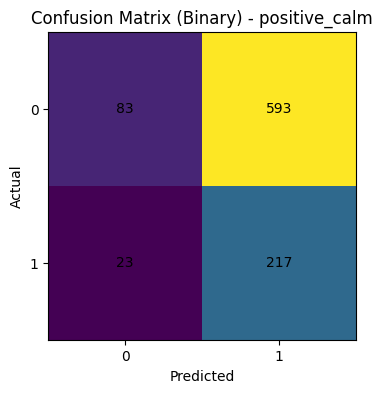

Saved: emotion_multilabel_figures_final\cm_positive_calm.png


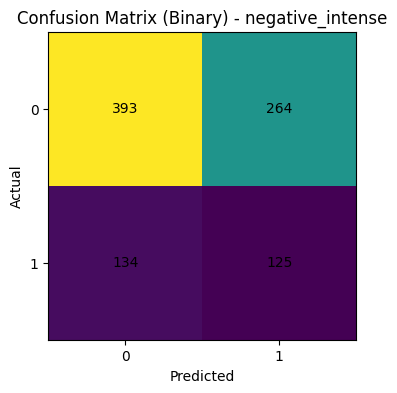

Saved: emotion_multilabel_figures_final\cm_negative_intense.png


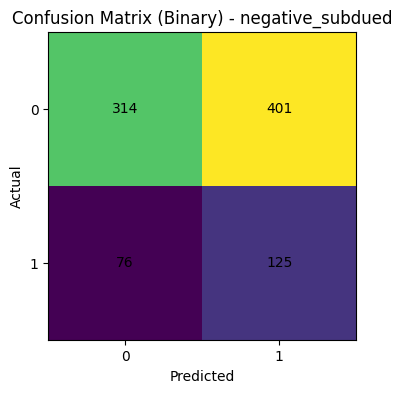

Saved: emotion_multilabel_figures_final\cm_negative_subdued.png


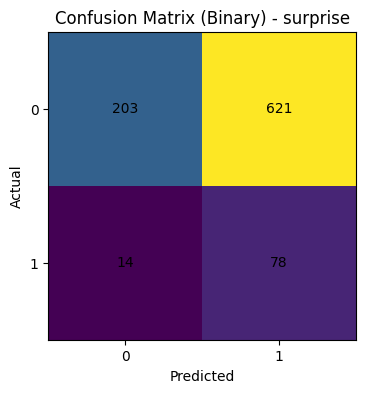

Saved: emotion_multilabel_figures_final\cm_surprise.png


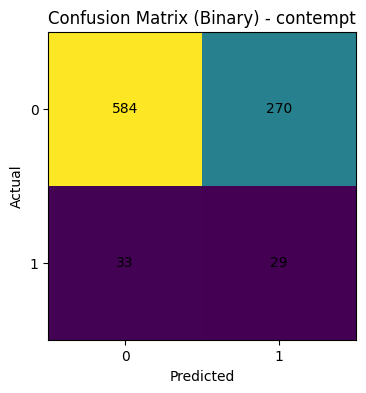

Saved: emotion_multilabel_figures_final\cm_contempt.png


In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for i, label in enumerate(groups):
    cm = confusion_matrix(test_true[:, i], test_pred[:, i])
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (Binary) - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])

    # annotate
    for (r,c), v in np.ndenumerate(cm):
        plt.text(c, r, str(v), ha="center", va="center")

    cm_path = os.path.join(OUT_DIR, f"cm_{label}.png")
    plt.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_path)

In [42]:
import os
OUT_DIR = "emotion_multilabel_figures_best_repro"
os.makedirs(OUT_DIR, exist_ok=True)

best_path = os.path.join(OUT_DIR, "best_multilabel_6group_resnet18_repro.pth")
history_path = os.path.join(OUT_DIR, "train_history_repro.npz")

print("OUT_DIR:", OUT_DIR)
print("best_path:", best_path)

OUT_DIR: emotion_multilabel_figures_best_repro
best_path: emotion_multilabel_figures_best_repro\best_multilabel_6group_resnet18_repro.pth


In [43]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [44]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_classes = 6

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)
print("Device:", device)

d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Device: cpu


In [45]:
import torch
import numpy as np

# Y must exist from your earlier multi-label creation step:
# Y = (G >= (alpha * top)).astype(np.float32)
assert "Y" in globals(), "Y not found. Re-run your multi-label creation cell first."

pos = torch.tensor(Y.sum(axis=0), dtype=torch.float32)
neg = torch.tensor(len(Y) - pos, dtype=torch.float32)

pos_weight = (neg / (pos + 1e-6)).clamp(max=10.0)
print("pos_weight:", pos_weight)

pos_weight: tensor([ 1.7494,  3.2545,  2.4256,  3.5496,  7.7407, 10.0000])


C:\Users\akind\AppData\Local\Temp\ipykernel_12268\173870649.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  neg = torch.tensor(len(Y) - pos, dtype=torch.float32)


In [46]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [47]:
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm

def evaluate(loader, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return micro, macro

# History containers
train_losses = []
val_micro_scores = []
val_macro_scores = []

EPOCHS = 20          # enough to show rise + peak + start of overfitting
best_macro = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    micro, macro = evaluate(val_loader, threshold=0.5)

    train_losses.append(avg_loss)
    val_micro_scores.append(micro)
    val_macro_scores.append(macro)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Micro-F1: {micro:.4f} | Macro-F1: {macro:.4f}")

    if macro > best_macro:
        best_macro = macro
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model (Macro-F1 = {best_macro:.4f})")

# Save history for plots (so you never lose it again)
np.savez(history_path,
         train_losses=np.array(train_losses),
         val_micro=np.array(val_micro_scores),
         val_macro=np.array(val_macro_scores))

print("\nBest val Macro-F1:", best_macro)
print("Saved history:", history_path)
print("Saved best model:", best_path)

Epoch 1/10: 100%|██████████| 534/534 [08:46<00:00,  1.01it/s]



Epoch 1/10 | Loss: 1.0872 | Micro-F1: 0.3400 | Macro-F1: 0.2098
✅ Saved new best model (Macro-F1 = 0.2098)


Epoch 2/10: 100%|██████████| 534/534 [09:11<00:00,  1.03s/it]



Epoch 2/10 | Loss: 1.0585 | Micro-F1: 0.3425 | Macro-F1: 0.2778
✅ Saved new best model (Macro-F1 = 0.2778)


Epoch 3/10: 100%|██████████| 534/534 [08:21<00:00,  1.07it/s]


...


Epoch 8/10 | Loss: 1.0202 | Micro-F1: 0.3618 | Macro-F1: 0.3121
✅ Saved new best model (Macro-F1 = 0.3121)


Epoch 9/10: 100%|██████████| 534/534 [10:06<00:00,  1.14s/it]



Epoch 9/10 | Loss: 1.0111 | Micro-F1: 0.3318 | Macro-F1: 0.2828


Epoch 10/10: 100%|██████████| 534/534 [09:52<00:00,  1.11s/it]



Epoch 10/10 | Loss: 1.0096 | Micro-F1: 0.3505 | Macro-F1: 0.2831

Best val Macro-F1: 0.3121465892869461
Saved history: emotion_multilabel_figures_best_repro\train_history_repro.npz
Saved best model: emotion_multilabel_figures_best_repro\best_multilabel_6group_resnet18_repro.pth


In [48]:
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm

def evaluate(loader, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return micro, macro

# History containers
train_losses = []
val_micro_scores = []
val_macro_scores = []

EPOCHS = 10          # enough to show rise + peak + start of overfitting
best_macro = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    micro, macro = evaluate(val_loader, threshold=0.5)

    train_losses.append(avg_loss)
    val_micro_scores.append(micro)
    val_macro_scores.append(macro)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Micro-F1: {micro:.4f} | Macro-F1: {macro:.4f}")

    if macro > best_macro:
        best_macro = macro
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model (Macro-F1 = {best_macro:.4f})")

# Save history for plots (so you never lose it again)
np.savez(history_path,
         train_losses=np.array(train_losses),
         val_micro=np.array(val_micro_scores),
         val_macro=np.array(val_macro_scores))

print("\nBest val Macro-F1:", best_macro)
print("Saved history:", history_path)
print("Saved best model:", best_path)

Epoch 1/10:  99%|█████████▉| 529/534 [09:45<00:05,  1.11s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix, hamming_loss
import matplotlib.pyplot as plt
import os

# Load best checkpoint
model.load_state_dict(torch.load(best_path, map_location=device))

def collect_probs_labels(loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

test_probs, test_true = collect_probs_labels(test_loader)

THRESH = 0.45
test_pred = (test_probs > THRESH).astype(int)
# Subset Accuracy (exact match of all 6 labels)
subset_acc = (test_pred == test_true).all(axis=1).mean()

# Hamming Loss (fraction of labels incorrectly predicted)
ham = hamming_loss(test_true, test_pred)

print("\n================ MULTI-LABEL FINAL TEST RESULTS ================\n")
print("Subset Accuracy:", subset_acc)
print("Hamming Loss:", ham)

print("TEST Micro-F1:", f1_score(test_true, test_pred, average="micro", zero_division=0))
print("TEST Macro-F1:", f1_score(test_true, test_pred, average="macro", zero_division=0))
print("\nReport:\n", classification_report(test_true, test_pred, target_names=groups, zero_division=0))

with open(os.path.join(OUT_DIR, "final_metrics.txt"), "w") as f:
    f.write(f"Subset Accuracy: {subset_acc}\n")
    f.write(f"Hamming Loss: {ham}\n")
    f.write(f"Micro-F1: {f1_score(test_true, test_pred, average='micro', zero_division=0)}\n")
    f.write(f"Macro-F1: {f1_score(test_true, test_pred, average='macro', zero_division=0)}\n")

# Per-class F1 bar chart
per_class_f1 = [f1_score(test_true[:, i], test_pred[:, i], zero_division=0) for i in range(len(groups))]

plt.figure(figsize=(8,4))
plt.bar(groups, per_class_f1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 (Multi-label 6-group)")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
f1_png = os.path.join(OUT_DIR, "per_class_f1_repro.png")
plt.savefig(f1_png, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", f1_png)

# Binary confusion matrices per class
for i, label in enumerate(groups):
    cm = confusion_matrix(test_true[:, i], test_pred[:, i])
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (Binary) - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])
    for (r,c), v in np.ndenumerate(cm):
        plt.text(c, r, str(v), ha="center", va="center")
    cm_png = os.path.join(OUT_DIR, f"cm_{label}_repro.png")
    plt.savefig(cm_png, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_png)

In [50]:
from sklearn.metrics import precision_score, recall_score

print("Micro Precision:", precision_score(test_true, test_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(test_true, test_pred, average="micro", zero_division=0))
print("Macro Precision:", precision_score(test_true, test_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(test_true, test_pred, average="macro", zero_division=0))

Micro Precision: 0.24439796832984761
Micro Recall   : 0.6926333615580017
Macro Precision: 0.23774736190968748
Macro Recall   : 0.6784046815044674
